Flagging Vendor Invoices for Manual Review
objective: Predict whether a vender should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

*Manual invoice review is time-consuming and does not scale with transaction volume.
*Abnormal frieght charges, pricing deviation delays often indicate errors dispute or compliance risk.
*An automated flagging system enables finanace teams to focus attention on high risk invoices while allowing low risk invoices to be processed automatically  

In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
conn = sqlite3.connect(
    r"C:\Users\akash\Downloads\machine learning project\data\inventory.db"
)

In [3]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

for table in tables['name']:
    print(f"\n{'='*50}")
    print(f"TABLE: {table}")
    print(f"{'='*50}")

    sample = pd.read_sql(
        f"SELECT * FROM {table} LIMIT 5",
        conn
    )

    display(sample)


TABLE: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1



TABLE: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.



TABLE: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None



TABLE: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01



TABLE: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
purchase_agg_df=pd.read_sql_query("""SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars,
    AVG(
        JULIANDAY(p.ReceivingDate) - JULIANDAY(p.PODate)
    ) AS avg_receiving_delay
FROM purchases p
GROUP BY PONumber""",conn)

In [6]:
pd.read_sql_query("""SELECT
    
    vi.PONumber,

    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,

    (JULIANDAY(vi.InvoiceDate) - JULIANDAY(vi.PODate))
        AS days_po_to_invoice,

    (JULIANDAY(vi.PayDate) - JULIANDAY(vi.InvoiceDate))
        AS days_to_pay

FROM vendor_invoice vi""",conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [7]:
print(type(pd.read_sql_query))
print(type(conn))

<class 'function'>
<class 'sqlite3.Connection'>


In [8]:
final_df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(
            JULIANDAY(p.ReceivingDate) - JULIANDAY(p.PODate)
        ) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,

    -- Invoice Features
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,

    ROUND(
        JULIANDAY(vi.InvoiceDate) - JULIANDAY(vi.PODate),
        0
    ) AS days_po_to_invoice,

    ROUND(
        JULIANDAY(vi.PayDate) - JULIANDAY(vi.InvoiceDate),
        0
    ) AS days_to_pay,

    -- Purchase Features
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi

LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)

final_df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


In [9]:
def create_invoice_risk_label(row):
    """
    Risk Label:
    1 = Risky Invoice
    0 = Normal Invoice
    """

    # Rule 1: Invoice total mismatch
    amount_mismatch = (
        abs(row['invoice_dollars'] - row['total_item_dollars'])
        > 5
    )

    # Rule 2: Abnormally high receiving delay
    high_receiving_delay = (
        row['avg_receiving_delay'] > 10
    )

    if amount_mismatch or high_receiving_delay:
        return 1

    return 0

In [10]:
final_df['invoice_risk_label'] = final_df.apply(
    create_invoice_risk_label,
    axis=1
)
final_df['invoice_risk_label'].value_counts()


invoice_risk_label
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='invoice_risk_label'>

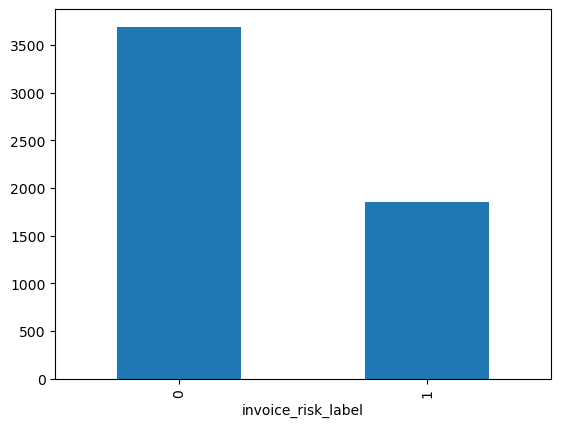

In [11]:
final_df['invoice_risk_label'].value_counts().plot(kind='bar')


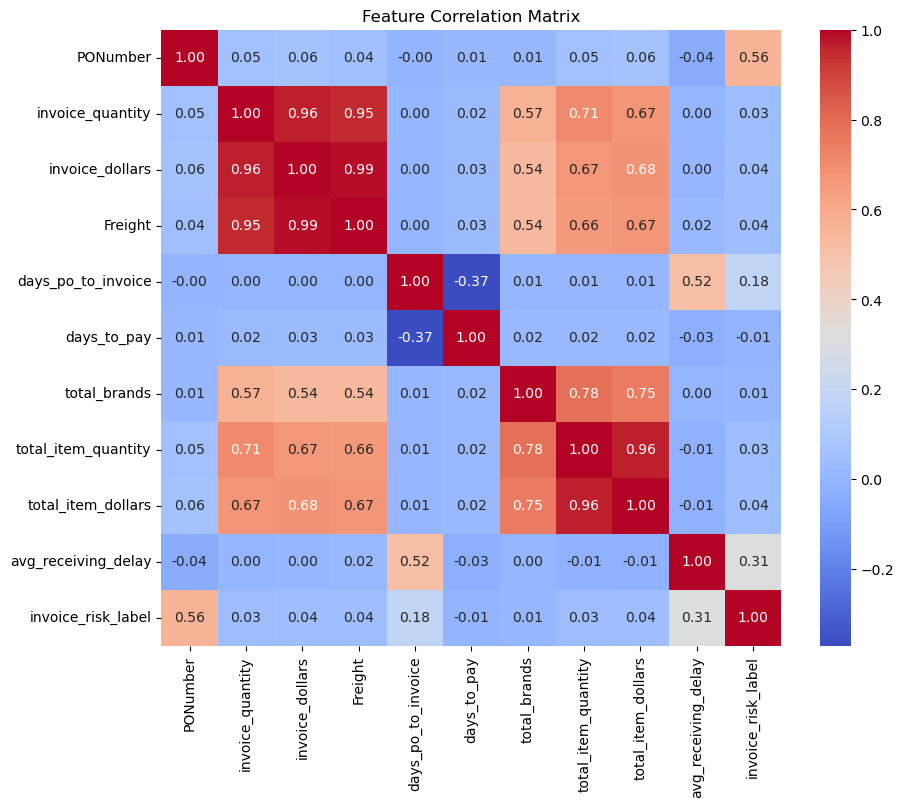

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    final_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Matrix')
plt.show()

In [13]:
flagged=final_df[final_df['invoice_risk_label']==1]
normal=final_df[final_df['invoice_risk_label']==0]

In [14]:
significant _features=[]
non_significant_features=[]
results=[]

SyntaxError: invalid syntax (782063222.py, line 1)

In [ ]:
metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]

In [ ]:
from scipy.stats import ttest_ind

flagged = final_df[final_df['invoice_risk_label'] == 1]
normal = final_df[final_df['invoice_risk_label'] == 0]

significant_features = []
non_significant_features = []
results = []

metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]

for feature in metrics:

    t_stat, p_value = ttest_ind(
        flagged[feature].dropna(),
        normal[feature].dropna(),
        equal_var=False
    )

    results.append({
        'feature': feature,
        't_statistic': t_stat,
        'p_value': p_value
    })

    if p_value < 0.05:
        significant_features.append(feature)
    else:
        non_significant_features.append(feature)

results_df = pd.DataFrame(results)

print("Significant Features:")
print(significant_features)

print("\nNon-Significant Features:")
print(non_significant_features)

results_df.sort_values('p_value')

In [ ]:
results

In [ ]:
x=final_df[['invoice_quantity','invoice_dollars','Freight','days_po_to_invoice','total_brands','total_item_quantity','total_item_dollars']]
y=final_df['invoice_risk_label']

In [ ]:
x.describe()

In [19]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Features and Target
X = final_df[
    [
        'invoice_quantity',
        'invoice_dollars',
        'Freight',
        'days_po_to_invoice',
        'total_brands',
        'total_item_quantity',
        'total_item_dollars'
    ]
]

y = final_df['invoice_risk_label']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []

# Train and Evaluate
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# Results Table
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df = results_df.sort_values(
    'F1 Score',
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.873760   0.916667  0.683784  0.783282
1        Decision Tree  0.818756   0.728997  0.727027  0.728011
0  Logistic Regression  0.671776   0.578947  0.059459  0.107843


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
from sklearn.metrics import accuracy_score

y_pred1 = model1.predict(X_test_scaled)
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred1))

y_pred2 = model2.predict(X_test_scaled)
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred2))

y_pred3 = model3.predict(X_test_scaled)
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred3))

Logistic Regression Accuracy: 0.6717763751127142
Decision Tree Accuracy: 0.8205590622182146
Random Forest Accuracy: 0.8719567177637512


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42
)

param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [10, None],

    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    scoring='f1',

    cv=3,

    n_jobs=1,

    verbose=2
)

grid_search.fit(
    X_train_scaled,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest F1 Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [26]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 200}

Best F1 Score:
0.794068951232434


In [28]:
best_rf = grid_search.best_estimator_

In [29]:
y_pred = best_rf.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8791704238052299
F1 Score: 0.7912772585669782


In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.98      0.91       739
           1       0.93      0.69      0.79       370

    accuracy                           0.88      1109
   macro avg       0.90      0.83      0.85      1109
weighted avg       0.89      0.88      0.87      1109



In [32]:
from sklearn.metrics import confusion_matrix
confusion_matrix(
    y_test,
    y_pred
)

array([[721,  18],
       [116, 254]])

In [33]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 200}
